# Gemini Object Detection Demo

Using Gemini's robotics capabilities for object detection with bounding boxes.

## Install Dependencies

We need the Google GenAI SDK, pandas for tables, and matplotlib for visualization.

In [15]:
!pip install google-genai pillow pandas matplotlib -q

## Import Libraries

In [3]:
import os
from google import genai
from google.genai import types
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import json

## Setup Gemini Client

Set your API key as an environment variable or replace the string below.

In [5]:
GEMINI_API_KEY = os.getenv('GEMINI_API_KEY')
client = genai.Client(api_key=GEMINI_API_KEY)

## Detect Objects with Bounding Boxes

This function sends an image to Gemini and requests object detection with bounding boxes.
Coordinates are normalized to 0-1000 range.

In [8]:
def detect_objects(image_path):
    """Detect objects and return bounding boxes using Gemini."""
    with open(image_path, 'rb') as f:
        image_bytes = f.read()
    
    prompt = """Detect all objects in this image and return bounding boxes.
    Return a JSON array with format:
    [{"box_2d": [ymin, xmin, ymax, xmax], "label": "object_name", "confidence": 0.95}]
    Normalize coordinates to 0-1000."""
    
    response = client.models.generate_content(
        model="gemini-robotics-er-1.5-preview",
        contents=[
            types.Part.from_bytes(data=image_bytes, mime_type='image/jpeg'),
            prompt
        ],
        config=types.GenerateContentConfig(
            temperature=0.3,
            response_mime_type="application/json"
        )
    )
    
    return json.loads(response.text)

## Run Detection

Replace `'your_image.jpg'` with the path to your image.

In [9]:
image_path = 'images/coco128_sample/127.png'

print("Running object detection...")
detections = detect_objects(image_path)
print(f"Found {len(detections)} objects!")

Running object detection...
Found 8 objects!


## Convert to DataFrame and Display Table

Create a nice table showing all detected objects with their coordinates.

In [10]:
# Create DataFrame
data = []
for det in detections:
    ymin, xmin, ymax, xmax = det['box_2d']
    data.append({
        'Object': det['label'],
        'Confidence': det.get('confidence', 'N/A'),
        'X_min': xmin,
        'Y_min': ymin,
        'X_max': xmax,
        'Y_max': ymax,
        'Width': xmax - xmin,
        'Height': ymax - ymin
    })

df = pd.DataFrame(data)
df

,Object,Confidence,X_min,Y_min,X_max,Y_max,Width,Height
0,coffee cup,N/A,597,463,884,715,287,252
1,cake slice,N/A,285,557,483,839,198,282
2,plate,N/A,166,608,577,944,411,336
3,spoon,N/A,544,570,671,744,127,174
4,book,N/A,403,408,603,600,200,192
5,knife,N/A,477,618,626,918,149,300
6,saucer,N/A,548,585,889,788,341,203
7,bag,N/A,303,254,911,513,608,259


## Save Results to CSV

Export detection results for later analysis.

In [11]:
csv_path = 'detections.csv'
df.to_csv(csv_path, index=False)
print(f"Results saved to {csv_path}")

Results saved to detections.csv


## Draw Bounding Boxes on Image

Visualize the detections by drawing boxes on the original image.

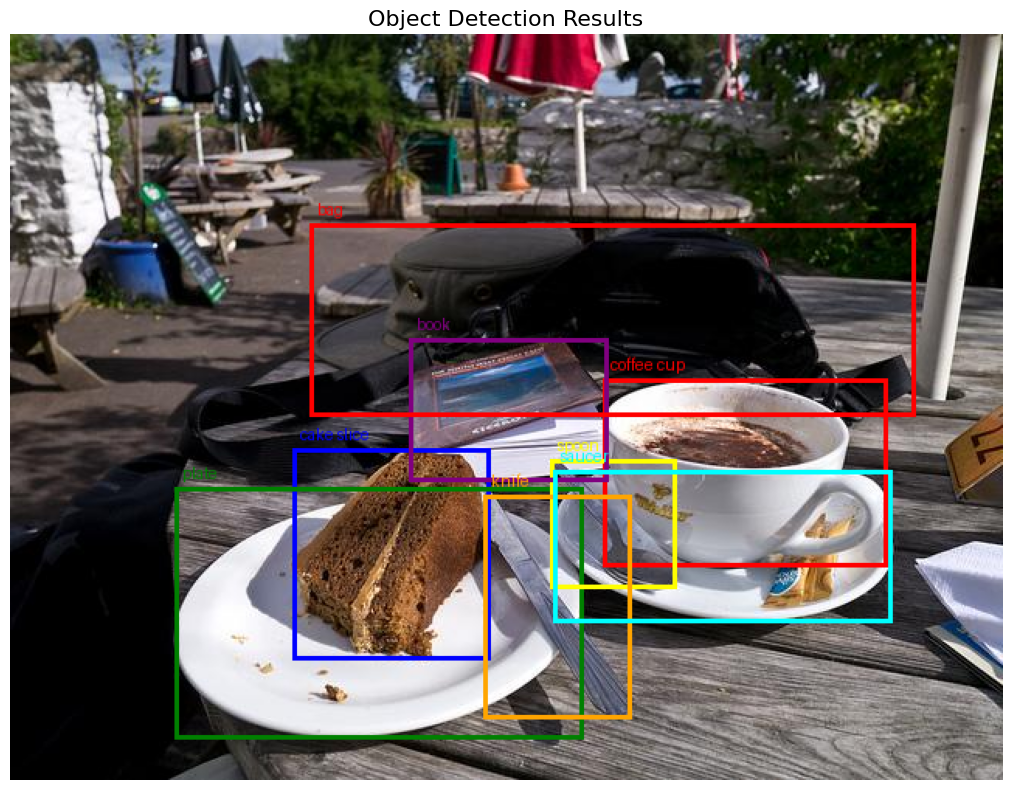

Annotated image saved!


In [12]:
def draw_boxes(image_path, detections):
    """Draw bounding boxes on image."""
    img = Image.open(image_path)
    draw = ImageDraw.Draw(img)
    width, height = img.size
    
    colors = ['red', 'blue', 'green', 'yellow', 'purple', 'orange', 'cyan']
    
    for idx, det in enumerate(detections):
        # Convert normalized coords to pixels
        ymin, xmin, ymax, xmax = det['box_2d']
        x1 = int(xmin * width / 1000)
        y1 = int(ymin * height / 1000)
        x2 = int(xmax * width / 1000)
        y2 = int(ymax * height / 1000)
        
        color = colors[idx % len(colors)]
        
        # Draw box and label
        draw.rectangle([x1, y1, x2, y2], outline=color, width=3)
        draw.text((x1+5, y1-15), det['label'], fill=color)
    
    return img

# Draw and display
annotated_img = draw_boxes(image_path, detections)

plt.figure(figsize=(12, 8))
plt.imshow(annotated_img)
plt.axis('off')
plt.title('Object Detection Results', fontsize=16)
plt.tight_layout()
plt.show()

annotated_img.save('annotated_image.jpg')
print("Annotated image saved!")